In [2]:
import pandas as pd
import os
import numpy as np
from glob import glob

In [2]:
# Operational models, more data, trained without outerTest
# For paper, we use the uncalibrated preds, which do still exist cleanly in the calibration csv predictions, just in o_pred col

dir = "/home/csutter/DRIVE-clean/operational_runs/set17_summer_examples/data_6_ensembling"  #/data_2_cnnpreds, /data_6_ensembling

files1 = glob(f"{dir}/*/*/*/*/*")
print(len(files1))

dir = "/home/csutter/DRIVE-clean/operational_runs/set18_summer_examples_2/data_6_ensembling"

files2 = glob(f"{dir}/*/*/*/*/*")
print(len(files2))

dir = "/home/csutter/DRIVE-clean/operational_runs/set19_summer_examples_3/data_6_ensembling"

files3 = glob(f"{dir}/*/*/*/*/*")
print(len(files3))


dir = "/home/csutter/DRIVE-clean/operational_runs/set20_summer_examples_4/data_6_ensembling"

files4 = glob(f"{dir}/*/*/*/*/*")
print(len(files4))


dir = "/home/csutter/DRIVE-clean/operational_runs/set21_summer_examples_5/data_6_ensembling"

files5 = glob(f"{dir}/*/*/*/*/*")
print(len(files5))

dir = "/home/csutter/DRIVE-clean/operational_runs/set22_summer_examples_6/data_6_ensembling"

files6 = glob(f"{dir}/*/*/*/*/*")
print(len(files6))


files = files1+files2+files3+files4+files5+files6

print(len(files)) # if doing data_2_cnnpreds, there will be 5x the amount bc of the ensemble

predcats = []

for f in files:
    d = pd.read_csv(f)
    # display(d.head(4))
    for p in d["select"]: # "select" for data_6_ensemble, or "model_pred" for data_2_cnnpreds
        predcats.append(p)

print(len(predcats))

54
52
30
27
25
25
213
497126


In [3]:
# set finds the unique list of predicted cats, then call on .count for each one (x) to display 

[[x,predcats.count(x)] for x in set(predcats)]


[['wet', 82169], ['dry', 389430], ['snow_severe', 6], ['poor_viz', 25521]]

In [8]:
(1-6/497126)*100

99.99879306252339

### Display severe snow cases

In [12]:
# need to check why there are less preds in ^ that list, compared to what is made in this file preds in pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_summer.csv"), which was created in /home/csutter/DRIVE-clean/weather_events/notebooks/investigation_MRMS.ipynb

df = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_summer.csv")
df = df.rename(columns = {"count":"cat_preds_count"})


pd.set_option('display.max_colwidth', None)

display(df.head(3))
print(sum(df[df["select"]=="snow_severe"]["cat_preds_count"]))
display(df[df["select"]=="snow_severe"])

fs = df[df["select"]=="snow_severe"]["predfile"]
print(len(fs))

ss_pred_imgpaths = []
sites = []
for f in fs:
    d1 = pd.read_csv(f)
    d1_ss = d1[d1["select"]=="snow_severe"]
    ss_imgs = list(d1_ss["img_orig"])
    sitename = list(d1_ss["site"])
    sites.append(sitename)
    for im in ss_imgs:
        ss_pred_imgpaths.append(im)

# print(ss_pred_imgpaths)
for i in ss_pred_imgpaths:
    print(i)

for f in fs:
    print(f)


,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime
0,No Precip,dry,1184,0.721268,0.000676,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000
1,No Precip,wet,1078,0.635638,0.006308,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000
2,Warm Rain,dry,11,0.394291,0.381818,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000


9


,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime
225,Hail/Mixed,snow_severe,1,0.329502,41.3,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2230/finalpreds.csv,20240710_2230
603,No Precip,snow_severe,1,0.247951,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0045/finalpreds.csv,20240620_0045
735,No Precip,snow_severe,1,0.186157,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0630/finalpreds.csv,20240620_0630
1227,No Precip,snow_severe,1,0.193109,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/30/20250730_0800/finalpreds.csv,20250730_0800
1279,No Precip,snow_severe,2,0.291225,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800
1381,No Precip,snow_severe,1,0.212560,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/30/20250630_0800/finalpreds.csv,20250630_0800
1509,No Precip,snow_severe,1,0.215572,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/28/20250628_0800/finalpreds.csv,20250628_0800
1616,No Precip,snow_severe,1,0.251157,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/20/20250620_0800/finalpreds.csv,20250620_0800


8
/home/csutter/cron/data/Skyline_2108/20240710/I_690_west_of_Exit_5_(Van_Vleck_Rd)__Westbound__Skyline_2108_2024-07-10-22:26:07.jpg
/home/csutter/cron/data/NYSDOT_4616518/20240620/Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-00:45:08.jpg
/home/csutter/cron/data/NYSDOT_4616518/20240620/Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-06:30:08.jpg
/home/csutter/cron/data/Skyline_5026/20250730/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-30-08:00:39.jpg
/home/csutter/cron/data/Skyline_5026/20250725/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-25-07:55:48.jpg
/home/csutter/cron/data/Skyline_5016/20250725/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-07-25-07:55:47.jpg
/home/csutter/cron/data/Skyline_5026/20250630/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-06-30-08:00:43.jpg
/home/csutter/cron/data/Skyline_5016/20250628/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-28-08:03:01.jpg
/home/csutter/cro

In [11]:
sites

[['Skyline_2108'],
 ['NYSDOT_4616518'],
 ['NYSDOT_4616518'],
 ['Skyline_5026'],
 ['Skyline_5026', 'Skyline_5016'],
 ['Skyline_5026'],
 ['Skyline_5016'],
 ['Skyline_5016']]

/home/csutter/cron/data/NYSDOT_4616518/20240620/Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-00:45:08.jpg


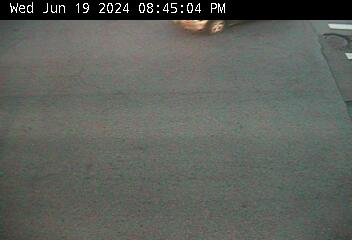

/home/csutter/cron/data/NYSDOT_4616518/20240620/Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-06:30:08.jpg


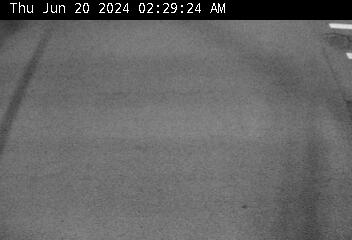

/home/csutter/cron/data/Skyline_2108/20240710/I_690_west_of_Exit_5_(Van_Vleck_Rd)__Westbound__Skyline_2108_2024-07-10-22:26:07.jpg


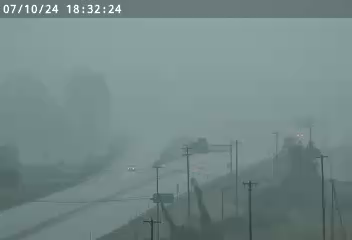

/home/csutter/cron/data/Skyline_5016/20250620/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-20-08:02:48.jpg


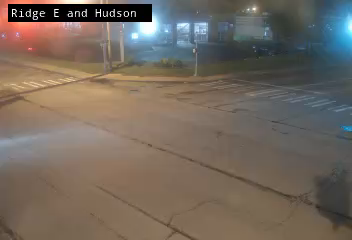

/home/csutter/cron/data/Skyline_5016/20250628/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-28-08:03:01.jpg


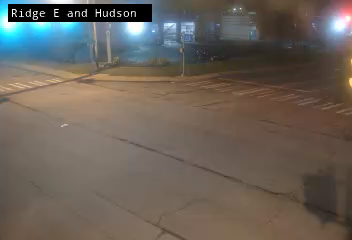

/home/csutter/cron/data/Skyline_5016/20250725/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-07-25-07:55:47.jpg


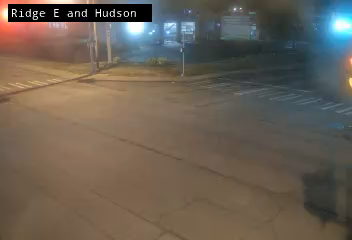

/home/csutter/cron/data/Skyline_5026/20250630/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-06-30-08:00:43.jpg


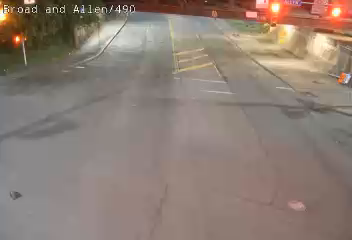

/home/csutter/cron/data/Skyline_5026/20250725/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-25-07:55:48.jpg


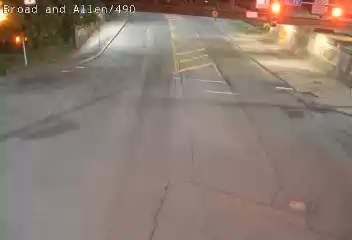

/home/csutter/cron/data/Skyline_5026/20250730/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-30-08:00:39.jpg


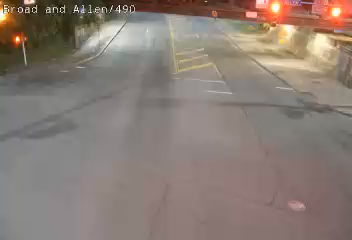

In [6]:
from PIL import Image

for f in np.sort(ss_pred_imgpaths):
    print(f)
    img = Image.open(f)
    img.show()


In [21]:
# look at what the other images of that type (the equivalent daytime one)

# 1 - grab other file path name from that day

days = [day[0:8] for day in df["datetime"]]
df["day"] = days

display(df.head(2))

# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2230/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0045/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0630/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/30/20250730_0800/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/30/20250630_0800/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/28/20250628_0800/finalpreds.csv
# /home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/20/20250620_0800/finalpreds.csv


# display(df.head(2))



# s1 = df[df["site"]=="NYSDOT_4616518"]


paired_dict = {"NYSDOT_4616518":"20240620","Skyline_2108":"20240710","Skyline_5016":"20250620","Skyline_5016":"20250628","Skyline_5016":"20250725","Skyline_5026":"20250630","Skyline_5026":"20250725","Skyline_5026":"20250730"}

print(paired_dict.values()) # note that this removes duplicate keys, so we are onlye left with one date per site, which honestly is fine for sampling since we just need one example of day image . There were onlye 4 unique sites that were severes now


sub1 = df[df["day"].isin(list(paired_dict.values()))]
display(sub1) 

dayfiles  = np.unique(sub1["predfile"])
print(dayfiles)

,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime,day
0,No Precip,dry,1184,0.721268,0.000676,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000,20240712
1,No Precip,wet,1078,0.635638,0.006308,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000,20240712


dict_values(['20240620', '20240710', '20250725', '20250730'])


,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime,day
50,Convective Rain,dry,5,0.662201,23.740000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2115/finalpreds.csv,20240710_2115,20240710
51,Convective Rain,wet,3,0.493784,28.166667,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2115/finalpreds.csv,20240710_2115,20240710
52,Hail/Mixed,dry,1,0.529415,3.700000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2115/finalpreds.csv,20240710_2115,20240710
53,Hail/Mixed,wet,4,0.393020,93.525000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2115/finalpreds.csv,20240710_2115,20240710
54,No Precip,dry,1862,0.702697,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2115/finalpreds.csv,20240710_2115,20240710
...,...,...,...,...,...,...,...,...
1277,No Precip,dry,2056,0.669049,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800,20250725
1278,No Precip,poor_viz,50,0.464566,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800,20250725
1279,No Precip,snow_severe,2,0.291225,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800,20250725
1280,No Precip,wet,256,0.580221,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800,20250725


['/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0000/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0015/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0030/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0045/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0100/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0115/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0130/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0145/finalpreds.csv'
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0200/finalpreds.csv'
 '/home/cs

In [22]:
# Why are there so many runs beyond just those set from the random summer sampling? Bc there are NCEI events that I ran!! See the 20240620 files above, there is convective rain, hail, etc. it must have been a major storm. 
#Figure out if i wanna remove some of these for my dissertation





/home/csutter/cron/data/NYSDOT_4616518/20240620/Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-20:00:07.jpg
dry


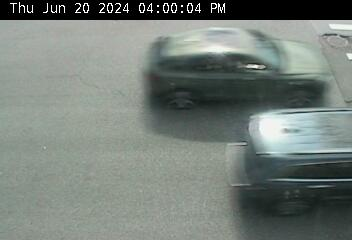

/home/csutter/cron/data/Skyline_2108/20240710/I_690_west_of_Exit_5_(Van_Vleck_Rd)__Westbound__Skyline_2108_2024-07-10-20:00:53.jpg
dry


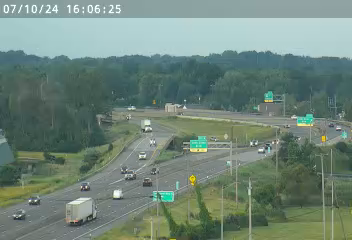

/home/csutter/cron/data/Skyline_5016/20250628/East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-28-20:00:52.jpg
dry


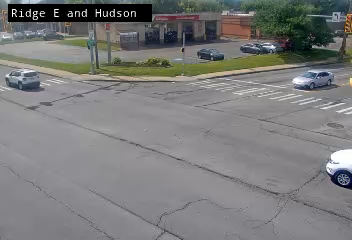

/home/csutter/cron/data/Skyline_5026/20250725/Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-25-20:00:55.jpg
dry


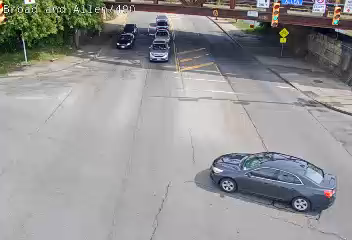

In [36]:
PAIRS: {"NYSDOT_4616518":"20240620","Skyline_2108":"20240710","Skyline_5016":"20250620","Skyline_5016":"20250628","Skyline_5016":"20250725","Skyline_5026":"20250630","Skyline_5026":"20250725","Skyline_5026":"20250730"}


dex1 = pd.read_csv('/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_2000/finalpreds.csv')
fex1 = dex1[dex1["site"]=="NYSDOT_4616518"]
f1 = fex1["img_orig"].item()
print(f1)
p1 = fex1["select"].item()
print(p1)
img = Image.open(f1)
img.show()



dex1 = pd.read_csv('/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2000/finalpreds.csv')
fex1 = dex1[dex1["site"]=="Skyline_2108"]
f1 = fex1["img_orig"].item()
print(f1)
p1 = fex1["select"].item()
print(p1)
img = Image.open(f1)
img.show()



dex1 = pd.read_csv('/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/28/20250628_2000/finalpreds.csv')
fex1 = dex1[dex1["site"]=="Skyline_5016"]
f1 = fex1["img_orig"].item()
print(f1)
p1 = fex1["select"].item()
print(p1)
img = Image.open(f1)
img.show()


dex1 = pd.read_csv('/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_2000/finalpreds.csv')
fex1 = dex1[dex1["site"]=="Skyline_5026"]
f1 = fex1["img_orig"].item()
print(f1)
p1 = fex1["select"].item()
print(p1)
img = Image.open(f1)
img.show()

# '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_2000/finalpreds.csv'

# '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/30/20250730_2000/finalpreds.csv']